In [ ]:
# download metadata
# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/votus_metadata_extended.tsv

--2025-10-27 08:45:42--  https://portal.nersc.gov/cfs/m342/UHGV/metadata/votus_metadata_extended.tsv
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.108, 128.55.206.112, 128.55.206.107, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134376248 (128M) [text/tab-separated-values]
Saving to: ‘votus_metadata_extended.tsv’

votus_metadata_exte 100%[===================>] 128.15M  35.9MB/s    in 3.7s    

2025-10-27 08:45:46 (34.4 MB/s) - ‘votus_metadata_extended.tsv’ saved [134376248/134376248]



In [11]:
# filter metadata to HQ viruses
import polars as pl

hq_votus = (
    pl.read_csv('votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'kmers_total_connections', 'kmers_host_agreement', 'host_prediction_method', 'crispr_total_connections', 'crispr_host_agreement'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .with_columns(pl.col('kmers_total_connections').cast(pl.Float64))
        .with_columns(pl.col('kmers_host_agreement').cast(pl.Float64))
)

print("Prop w/PHIST prediction:", hq_votus.filter(pl.col('kmers_total_connections') > 0).height / hq_votus.height)
print("Prop using PHIST prediction:", hq_votus.filter(pl.col('host_prediction_method') == 'PHIST').height / hq_votus.height)
print(
    hq_votus.filter(pl.col('host_prediction_method') == 'PHIST').with_columns(pl.col('kmers_total_connections').cast(pl.Float64))[['kmers_total_connections']].describe()
)
print(
    hq_votus.filter(pl.col('host_prediction_method') == 'PHIST').with_columns(pl.col('kmers_host_agreement').cast(pl.Float64))[['kmers_host_agreement']].describe()
)

Prop w/PHIST prediction: 0.5950203428730396
Prop using PHIST prediction: 0.13028132280835972
shape: (9, 2)
┌────────────┬─────────────────────────┐
│ statistic  ┆ kmers_total_connections │
│ ---        ┆ ---                     │
│ str        ┆ f64                     │
╞════════════╪═════════════════════════╡
│ count      ┆ 7493.0                  │
│ null_count ┆ 0.0                     │
│ mean       ┆ 495.658214              │
│ std        ┆ 1674.725497             │
│ min        ┆ 1.0                     │
│ 25%        ┆ 10.0                    │
│ 50%        ┆ 58.0                    │
│ 75%        ┆ 253.0                   │
│ max        ┆ 24425.0                 │
└────────────┴─────────────────────────┘
shape: (9, 2)
┌────────────┬──────────────────────┐
│ statistic  ┆ kmers_host_agreement │
│ ---        ┆ ---                  │
│ str        ┆ f64                  │
╞════════════╪══════════════════════╡
│ count      ┆ 7493.0               │
│ null_count ┆ 0.0                  

In [8]:
print("Prop w/CRISPR prediction:", hq_votus.filter(pl.col('host_prediction_method') == 'CRISPR').height / hq_votus.height)
print(
    hq_votus.filter(pl.col('host_prediction_method') == 'CRISPR').with_columns(pl.col('crispr_total_connections').cast(pl.Float64))[['crispr_total_connections']].describe()
)
print(
    hq_votus.filter(pl.col('host_prediction_method') == 'CRISPR').with_columns(pl.col('crispr_host_agreement').cast(pl.Float64))[['crispr_host_agreement']].describe()
)

Prop w/CRISPR prediction: 0.7937024028932086
shape: (9, 2)
┌────────────┬──────────────────────────┐
│ statistic  ┆ crispr_total_connections │
│ ---        ┆ ---                      │
│ str        ┆ f64                      │
╞════════════╪══════════════════════════╡
│ count      ┆ 45649.0                  │
│ null_count ┆ 0.0                      │
│ mean       ┆ 347.037679               │
│ std        ┆ 726.846993               │
│ min        ┆ 1.0                      │
│ 25%        ┆ 25.0                     │
│ 50%        ┆ 98.0                     │
│ 75%        ┆ 334.0                    │
│ max        ┆ 35982.0                  │
└────────────┴──────────────────────────┘
shape: (9, 2)
┌────────────┬───────────────────────┐
│ statistic  ┆ crispr_host_agreement │
│ ---        ┆ ---                   │
│ str        ┆ f64                   │
╞════════════╪═══════════════════════╡
│ count      ┆ 45649.0               │
│ null_count ┆ 0.0                   │
│ mean       ┆ 90.667811

In [13]:
import polars as pl

# filter metadata to HQ viruses
hq_votus = (
    pl.read_csv('votus_metadata_extended.tsv', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'uhgv_taxonomy', 'host_lineage_gtdb_r207', 'crispr_host_lineage_gtdb_r207', 'kmers_host_lineage_gtdb_r207', 'host_prediction_method', 'lifestyle', 'lifestyle_evidence'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .with_columns([
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_species'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_genus'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_family'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_order'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_class'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_phylum'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vOTU-')).then(pl.col('uhgv_taxonomy').str.split(';vOTU-').list[-1]).otherwise(pl.lit(None)).alias('virus_species'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBGEN-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBGEN-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subgenus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vGENUS-')).then(pl.col('uhgv_taxonomy').str.split(';vGENUS-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_genus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBFAM-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subfamily'),
            pl.when(pl.col('uhgv_taxonomy').str.contains('vFAM-')).then(pl.col('uhgv_taxonomy').str.split('vFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_family'),
        ])
)

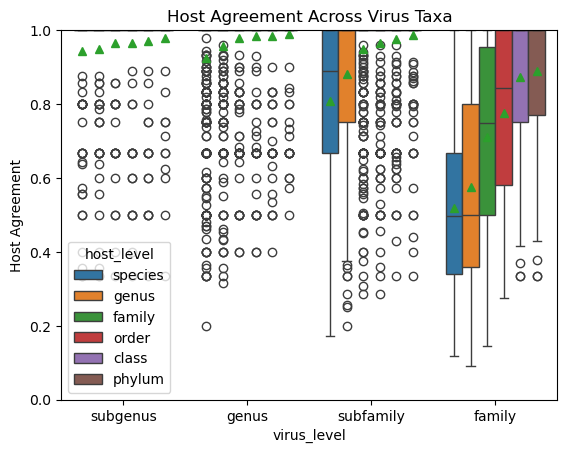

In [12]:
host_stats_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    for host_level in ['species', 'genus', 'family', 'order', 'class', 'phylum']:
        host_stats_lst.append(
            hq_votus
                .filter(pl.col('host_prediction_method') == 'PHIST')
                .group_by([f'host_{host_level}', f'virus_{virus_level}'])
                .agg([
                    pl.len().alias('host_taxa_count')
                ])
                .group_by(f'virus_{virus_level}')
                .agg([
                    pl.col('host_taxa_count').sum().alias('virus_total'),
                    pl.col('host_taxa_count').max().alias('virus_max_host_count')
                ])
                .filter(pl.col('virus_total') >= 3)
                .with_columns([
                    (pl.col('virus_max_host_count') / pl.col('virus_total')).alias('host_agreement'),
                    pl.lit(host_level).alias('host_level'),
                    pl.lit(virus_level).alias('virus_level')
                ])
                [['host_agreement', 'host_level', 'virus_level']]
        )

plot_df = pl.concat(host_stats_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=plot_df.to_pandas(), y='host_agreement', x='virus_level', hue='host_level', showmeans=True)
plt.ylim(0,1)
plt.ylabel('Host Agreement')
plt.title('Host Agreement Across Virus Taxa')
plt.show()

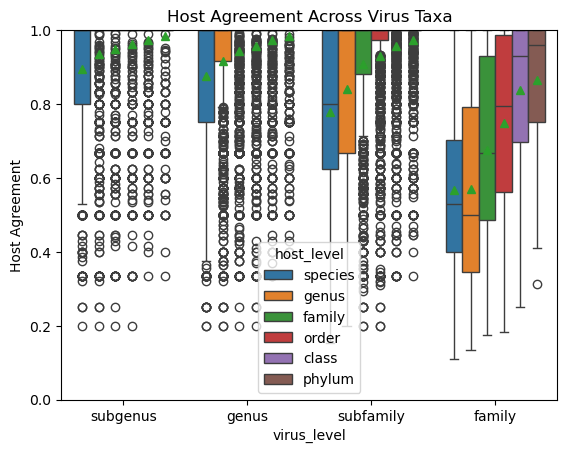

In [13]:
host_stats_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    for host_level in ['species', 'genus', 'family', 'order', 'class', 'phylum']:
        host_stats_lst.append(
            hq_votus
                .filter(pl.col('host_prediction_method') == 'CRISPR')
                .group_by([f'host_{host_level}', f'virus_{virus_level}'])
                .agg([
                    pl.len().alias('host_taxa_count')
                ])
                .group_by(f'virus_{virus_level}')
                .agg([
                    pl.col('host_taxa_count').sum().alias('virus_total'),
                    pl.col('host_taxa_count').max().alias('virus_max_host_count')
                ])
                .filter(pl.col('virus_total') >= 3)
                .with_columns([
                    (pl.col('virus_max_host_count') / pl.col('virus_total')).alias('host_agreement'),
                    pl.lit(host_level).alias('host_level'),
                    pl.lit(virus_level).alias('virus_level')
                ])
                [['host_agreement', 'host_level', 'virus_level']]
        )

plot_df = pl.concat(host_stats_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=plot_df.to_pandas(), y='host_agreement', x='virus_level', hue='host_level', showmeans=True)
plt.ylim(0,1)
plt.ylabel('Host Agreement')
plt.title('Host Agreement Across Virus Taxa')
plt.show()

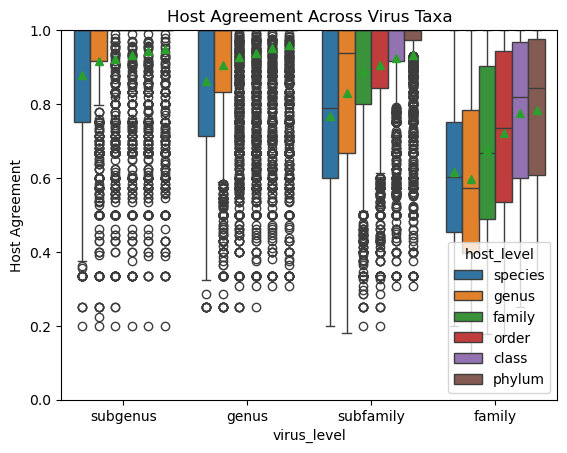

In [14]:
host_stats_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    for host_level in ['species', 'genus', 'family', 'order', 'class', 'phylum']:
        host_stats_lst.append(
            hq_votus
                .group_by([f'host_{host_level}', f'virus_{virus_level}'])
                .agg([
                    pl.len().alias('host_taxa_count')
                ])
                .group_by(f'virus_{virus_level}')
                .agg([
                    pl.col('host_taxa_count').sum().alias('virus_total'),
                    pl.col('host_taxa_count').max().alias('virus_max_host_count')
                ])
                .filter(pl.col('virus_total') >= 3)
                .with_columns([
                    (pl.col('virus_max_host_count') / pl.col('virus_total')).alias('host_agreement'),
                    pl.lit(host_level).alias('host_level'),
                    pl.lit(virus_level).alias('virus_level')
                ])
                [['host_agreement', 'host_level', 'virus_level']]
        )

plot_df = pl.concat(host_stats_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=plot_df.to_pandas(), y='host_agreement', x='virus_level', hue='host_level', showmeans=True)
plt.ylim(0,1)
plt.ylabel('Host Agreement')
plt.title('Host Agreement Across Virus Taxa')
plt.show()

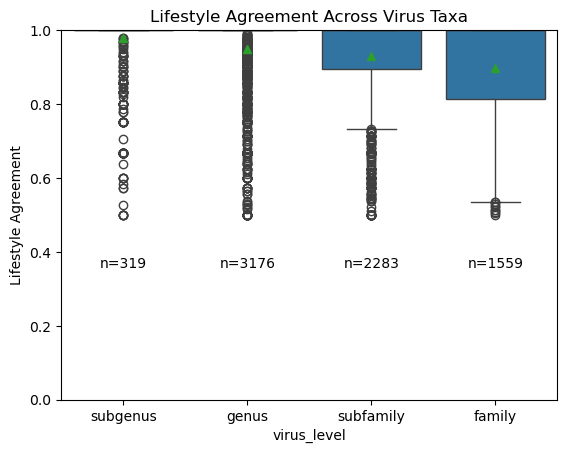

In [15]:
lifestyle_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    lifestyle_lst.append(
        hq_votus
            .filter(pl.col('lifestyle_evidence') == 'BACPHLIP')
            .group_by(['lifestyle', f'virus_{virus_level}'])
            .agg([
                pl.len().alias('lifestyle_count')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('lifestyle_count').sum().alias('virus_total'),
                pl.col('lifestyle_count').max().alias('virus_max_lifestyle_count')
            ])
            .filter(pl.col('virus_total') >= 3)
            .with_columns([
                (pl.col('virus_max_lifestyle_count') / pl.col('virus_total')).alias('lifestyle_agreement'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['lifestyle_agreement', 'virus_level']]
    )

plot_df = pl.concat(lifestyle_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.boxplot(data=plot_df.to_pandas(), y='lifestyle_agreement', x='virus_level', showmeans=True)

# Compute counts using Polars (faster)
counts = (
    plot_df
    .group_by("virus_level")
    .len()
    .sort("virus_level")
)

# Add counts to the plot
for i, row in enumerate(counts.iter_rows()):
    cat, count = row
    ax.text(i, 
            plot_df['lifestyle_agreement'].min() - 0.15,  # position slightly above top
            f"n={count}", 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            color='black')

plt.ylim(0,1)
plt.ylabel('Lifestyle Agreement')
plt.title('Lifestyle Agreement Across Virus Taxa')
plt.show()

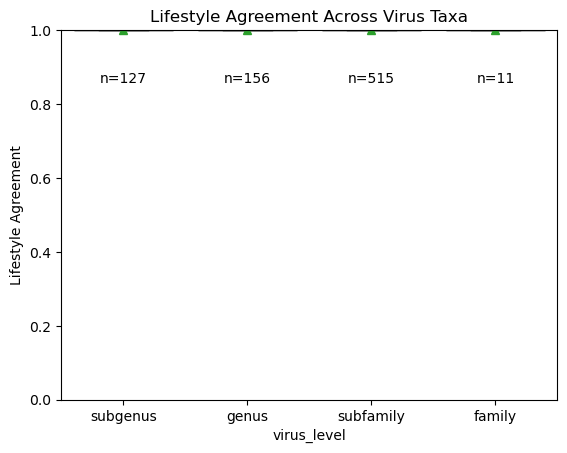

In [11]:
lifestyle_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    lifestyle_lst.append(
        hq_votus
            .filter(pl.col('lifestyle_evidence') == 'integrase')
            .group_by(['lifestyle', f'virus_{virus_level}'])
            .agg([
                pl.len().alias('lifestyle_count')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('lifestyle_count').sum().alias('virus_total'),
                pl.col('lifestyle_count').max().alias('virus_max_lifestyle_count')
            ])
            .filter(pl.col('virus_total') >= 3)
            .with_columns([
                (pl.col('virus_max_lifestyle_count') / pl.col('virus_total')).alias('lifestyle_agreement'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['lifestyle_agreement', 'virus_level']]
    )

plot_df = pl.concat(lifestyle_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.boxplot(data=plot_df.to_pandas(), y='lifestyle_agreement', x='virus_level', showmeans=True)

# Compute counts using Polars (faster)
counts = (
    plot_df
    .group_by("virus_level")
    .len()
    .sort("virus_level")
)

# Add counts to the plot
for i, row in enumerate(counts.iter_rows()):
    cat, count = row
    ax.text(i, 
            plot_df['lifestyle_agreement'].min() - 0.15,  # position slightly above top
            f"n={count}", 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            color='black')

# plot n=count of viruses used per box


plt.ylim(0,1)
plt.ylabel('Lifestyle Agreement')
plt.title('Lifestyle Agreement Across Virus Taxa')
plt.show()

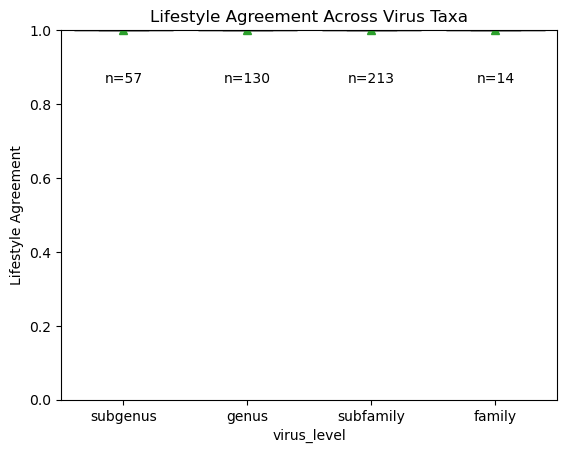

In [12]:
lifestyle_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    lifestyle_lst.append(
        hq_votus
            .filter(pl.col('lifestyle_evidence') == 'geNomad')
            .group_by(['lifestyle', f'virus_{virus_level}'])
            .agg([
                pl.len().alias('lifestyle_count')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('lifestyle_count').sum().alias('virus_total'),
                pl.col('lifestyle_count').max().alias('virus_max_lifestyle_count')
            ])
            .filter(pl.col('virus_total') >= 3)
            .with_columns([
                (pl.col('virus_max_lifestyle_count') / pl.col('virus_total')).alias('lifestyle_agreement'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['lifestyle_agreement', 'virus_level']]
    )

plot_df = pl.concat(lifestyle_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.boxplot(data=plot_df.to_pandas(), y='lifestyle_agreement', x='virus_level', showmeans=True)

# Compute counts using Polars (faster)
counts = (
    plot_df
    .group_by("virus_level")
    .len()
    .sort("virus_level")
)

# Add counts to the plot
for i, row in enumerate(counts.iter_rows()):
    cat, count = row
    ax.text(i, 
            plot_df['lifestyle_agreement'].min() - 0.15,  # position slightly above top
            f"n={count}", 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            color='black')

plt.ylim(0,1)
plt.ylabel('Lifestyle Agreement')
plt.title('Lifestyle Agreement Across Virus Taxa')
plt.show()

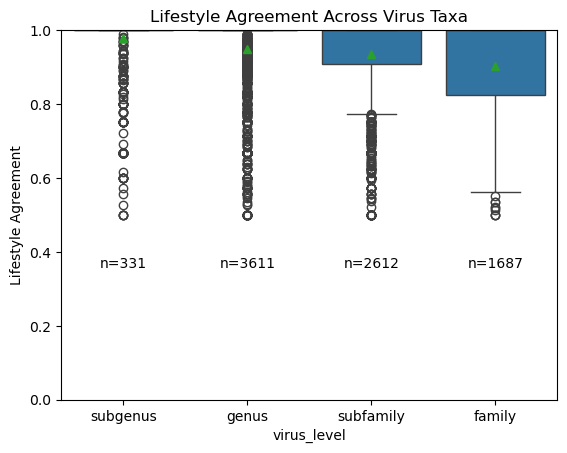

In [16]:
lifestyle_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    lifestyle_lst.append(
        hq_votus
            .group_by(['lifestyle', f'virus_{virus_level}'])
            .agg([
                pl.len().alias('lifestyle_count')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('lifestyle_count').sum().alias('virus_total'),
                pl.col('lifestyle_count').max().alias('virus_max_lifestyle_count')
            ])
            .filter(pl.col('virus_total') >= 3)
            .with_columns([
                (pl.col('virus_max_lifestyle_count') / pl.col('virus_total')).alias('lifestyle_agreement'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['lifestyle_agreement', 'virus_level']]
    )

plot_df = pl.concat(lifestyle_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.boxplot(data=plot_df.to_pandas(), y='lifestyle_agreement', x='virus_level', showmeans=True)

# Compute counts using Polars (faster)
counts = (
    plot_df
    .group_by("virus_level")
    .len()
    .sort("virus_level")
)

# Add counts to the plot
for i, row in enumerate(counts.iter_rows()):
    cat, count = row
    ax.text(i, 
            plot_df['lifestyle_agreement'].min() - 0.15,  # position slightly above top
            f"n={count}", 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            color='black')

plt.ylim(0,1)
plt.ylabel('Lifestyle Agreement')
plt.title('Lifestyle Agreement Across Virus Taxa')
plt.show()